In [1]:
import json
import ast
import numpy as np
import matplotlib.pyplot as plt
import rich

In [3]:
with open("8b_lora_negoeval_subsample_v2.json") as f:
    llama_8b_lora = json.load(f)

with open("8b_negoeval_subsample_v2.json") as f:
    llama_8b = json.load(f) 

In [29]:
def get_rewards_score_list(llama):
    result_list = []
    for c in llama:
        s = c['rewards']
        result = {}
        for line in s.strip().splitlines():
            if not line.strip():
                continue
            key, value_str = line.split(":", 1)
            key = key.strip()
            result[key] = ast.literal_eval(value_str.strip())
        result_list.append(result)
    return result_list

In [30]:
llama_8b_lora_rewards = get_rewards_score_list(llama_8b_lora)
llama_8b_rewards = get_rewards_score_list(llama_8b)

In [ ]:
def extract_samples(group_dict):
    samples = []
    for country, (overall, details) in group_dict.items():
        samples.append(details)
    return samples

def compute_stats(samples, sub_categories):
    means = {}
    stds = {}
    for sub in sub_categories:                        
        scores = [(sample[0][sub] + sample[1][sub]) / 2 for sample in samples]
        means[sub] = np.mean(scores)
        stds[sub] = np.std(scores)
    return means, stds


llama_8b_lora_store = []
llama_8b_store = []
for l in llama_8b_lora_rewards:
    llama_8b_lora_store.append(extract_samples(l))
for l in llama_8b_rewards:
    llama_8b_store.append(extract_samples(l))
    
sub_categories = list(llama_8b_lora_store[0][0].keys())
means_llama_8b_lora, stds_llama_8b_lora = compute_stats(llama_8b_lora_store, sub_categories)
means_llama_8b, stds_llama_8b = compute_stats(llama_8b_store, sub_categories)
# means_group2, stds_group2 = compute_stats(group2_samples, sub_categories)
# whole = group1_samples + group2_samples

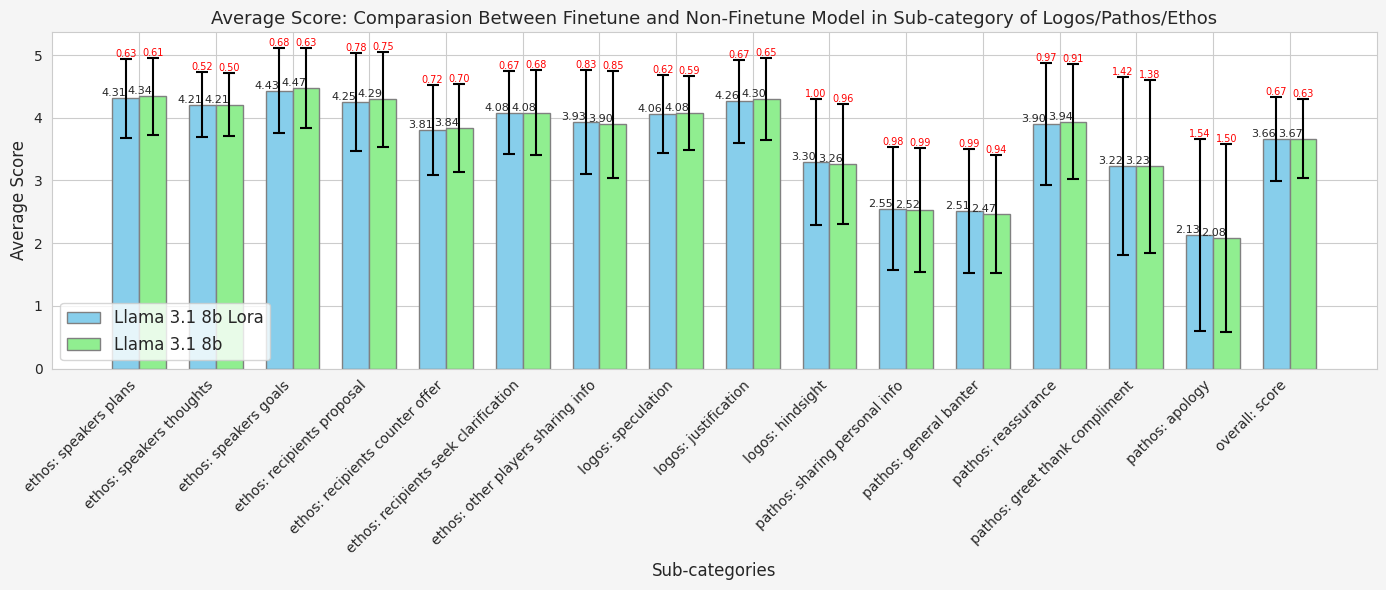

In [79]:
import seaborn as sns
def transform_label(label):
    parts = label.split('_')
    if len(parts) > 1:
        return parts[0] + ': ' + ' '.join(parts[1:])
    else:
        return label
transformed_labels = [transform_label(label) for label in sub_categories]

x = np.arange(len(sub_categories))
width = 0.35

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(14, 6), facecolor='whitesmoke')
fig.patch.set_facecolor('whitesmoke')

error_kw = dict(lw=1.5, capsize=4, capthick=1.5)

bars1 = ax.bar(x - width/2, [means_llama_8b_lora[sub] for sub in sub_categories], width,
               yerr=[stds_llama_8b_lora[sub] for sub in sub_categories],
               error_kw=error_kw,
               label='Llama 3.1 8b Lora', color='skyblue', edgecolor='gray')
bars2 = ax.bar(x + width/2, [means_llama_8b[sub] for sub in sub_categories], width,
               yerr=[stds_llama_8b[sub] for sub in sub_categories],
               error_kw=error_kw,
               label='Llama 3.1 8b', color='lightgreen', edgecolor='gray')

ax.set_xlabel('Sub-categories', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Average Score: Comparasion Between Finetune and Non-Finetune Model in Sub-category of Logos/Pathos/Ethos', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(transformed_labels, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12)

def add_value_labels(bars, std_values):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        std = std_values[i]
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
                ha='right', va='bottom', fontsize=8, fontweight='normal')
        ax.text(bar.get_x() + bar.get_width()/2, height + std, f'{std:.2f}', 
                ha='center', va='bottom', fontsize=7, color='red')

add_value_labels(bars1, [stds_llama_8b_lora[sub] for sub in sub_categories])
add_value_labels(bars2, [stds_llama_8b[sub] for sub in sub_categories])

plt.tight_layout()
plt.show()

## Read Reasoning 

In [4]:
index = 0
rich.print(f"Intent Dialogue:\n{llama_8b[index]['intent_dialogue']}")
rich.print(f"Reasoning:\n{llama_8b[index]['reasoning']}")
rich.print(f"Rewards:\n{llama_8b[index]['rewards']}")

Intent Dialogue:
0 FRANCE -> ENGLAND: Bonjour England, I see you're interested in negotiating with me. I'm glad we can have this 
conversation. I'm looking to strengthen my position in the Mediterranean, can we discuss possible arrangements? 
Perhaps we could exchange information on our future plans?
1 ENGLAND -> FRANCE: I'm happy to discuss arrangements that benefit both our positions, France. However, I must 
prioritize England's interests. What specific assistance do you think we could provide each other in the 
Mediterranean?
2 FRANCE -> ENGLAND: I see you're prioritizing England's interests, that's understandable. However, I'd like to 
remind you that France and England have a long history of cooperation in the Mediterranean. Perhaps we could 
discuss a possible alliance to counterbalance the growing power of Germany and Italy in the area? I'm willing to 
offer you some concessions to strengthen our position, but I need to know what you're willing to commit to.
3 ENGLAND -> FRANCE: I appreciate your offer, France, but I must consider the threat that Germany poses to our 
shared interests. Have you given any thought to how we can counter their potential advances in the North Sea? 
Perhaps we could discuss a possible alliance to contain them?
4 FRANCE -> ENGLAND: I'm glad we're discussing a potential alliance, England. However, I'm concerned about 
Germany's movements in the North Sea. Have you considered a possible alliance to contain them and protect our 
shared interests?
5 ENGLAND -> FRANCE: I'm hesitant to commit to an alliance without knowing more about your plans in the 
Mediterranean, France. Can you provide more details on your proposed concessions?
6 FRANCE -> ENGLAND: I'm glad we're discussing a potential alliance, England. However, I must remind you that 
France's position in the Mediterranean is crucial to our shared interests. I'd like to propose a compromise: if you
agree to support my movements in the Mediterranean, I'll consider working with you to contain Germany's advances in
the North Sea. What are your thoughts on this proposal?
7 ENGLAND -> FRANCE: I'm intrigued by your proposal, France, but I still need to prioritize England's interests. 
Can you give me more details on how you plan to strengthen your position in the Mediterranean and what concessions 
you're willing to offer in return for our support?
8 FRANCE -> ENGLAND: I see we're discussing a potential alliance to counterbalance Germany and Italy in the 
Mediterranean, England. That's a crucial area for France's security. However, I'd like to bring up a specific 
concern I have regarding Russia's movements in the north. Have you thought about how we could work together to 
contain their potential advances? I'm willing to commit to supporting your movements in the Mediterranean if you're
willing to consider this alliance with me.
9 ENGLAND -> FRANCE: France, I'm not sure I'm comfortable with the idea of forming an alliance with you just yet. 
I'd like to see more concrete plans from you on how we can work together to counter Germany's advances in the North
Sea. Can you provide more details on your proposal?
10 FRANCE -> ENGLAND: I think we're getting somewhere, England. I'm willing to make some concessions in the 
Mediterranean, but I need to know that you're committed to containing Germany's advances in the North Sea. Can we 
agree on a joint strategy to counter their movements and protect our shared interests in the region?
11 ENGLAND -> FRANCE: I appreciate your persistence, France, but I still have my reservations about forming an 
alliance with France. Can we explore other possible arrangements that could strengthen our position in the North 
Sea and protect our shared interests from Germany's advances?
12 FRANCE -> ENGLAND: I understand your concerns about Germany's advances in the North Sea, England. In light of 
this, I'd like to propose a compromise: if you agree to support my movements in the Mediterranean, I'll consider 
working with yo

Reasoning:
Environment comments: terminated: The conversation is too long; 
Agent 1 comments:
ethos_speakers_plans: Sam clearly states his intention to strengthen France's position in the Mediterranean.
ethos_speakers_thoughts: Sam demonstrates understanding of the geopolitical situation, particularly regarding 
Germany and Italy.
ethos_speakers_goals: Sam articulates his goal of forming an alliance to counterbalance threats, which builds 
credibility.
ethos_recipients_proposal: Sam's proposal for mutual support in the Mediterranean is clear and aligns with his 
goals.
ethos_recipients_counter_offer: Sam's counter-offers are constructive, aiming for a compromise that benefits both 
parties.
ethos_recipients_seek_clarification: Sam effectively seeks clarification on Emily's stance and concerns.
ethos_other_players_sharing_info: Sam shares insights about other players' movements, particularly Russia's, which 
is relevant.
logos_speculation: Sam speculates logically about the potential threats from Germany and Italy.
logos_justification: Sam justifies his requests by linking them to the broader strategic context.
logos_hindsight: Sam reflects on past interactions and uses them to inform his current proposals.
pathos_sharing_personal_info: Sam shares his thoughts on the importance of cooperation, fostering connection.
pathos_general_banter: Sam maintains a professional tone but lacks light-hearted banter.
pathos_reassurance: Sam reassures Emily of his commitment to mutual interests, indicating support.
pathos_greet_thank_compliment: Sam's greetings and compliments are polite but not overly warm.
pathos_apology: Sam does not offer apologies, as the context does not require them.
Agent 2 comments:
ethos_speakers_plans: Emily expresses her need to prioritize England's interests, which is clear but somewhat 
defensive.
ethos_speakers_thoughts: Emily shares her concerns about Germany, showing some understanding of the situation.
ethos_speakers_goals: Emily's goal of protecting England's interests is clear, but she lacks specific commitments.
ethos_recipients_proposal: Emily proposes to reassess the situation after the next move, which is vague.
ethos_recipients_counter_offer: Emily's counter-offers are cautious and lack clarity, making them less 
constructive.
ethos_recipients_seek_clarification: Emily seeks clarification on Sam's plans, indicating a desire to understand.
ethos_other_players_sharing_info: Emily does not share much information about other players, limiting her 
credibility.
logos_speculation: Emily speculates about Germany's potential advances but does not provide strong rationale.
logos_justification: Emily's justifications for her positions are somewhat weak and lack depth.
logos_hindsight: Emily does not reflect on past actions or lessons learned, which could inform her decisions.
pathos_sharing_personal_info: Emily does not share personal thoughts or feelings, which could foster connection.
pathos_general_banter: Emily maintains a serious tone, lacking light-hearted conversation.
pathos_reassurance: Emily does not provide reassurance, which could help build rapport.
pathos_greet_thank_compliment: Emily's greetings are polite but lack warmth or gratitude.
pathos_apology: Emily does not offer apologies, as the context does not require them.

Rewards:
England: (3.466666666666667, {'ethos_speakers_plans': 4.0, 'ethos_speakers_thoughts': 4.0, 'ethos_speakers_goals': 
4.0, 'ethos_recipients_proposal': 4.0, 'ethos_recipients_counter_offer': 4.0, 
'ethos_recipients_seek_clarification': 4.0, 'ethos_other_players_sharing_info': 4.0, 'logos_speculation': 4.0, 
'logos_justification': 4.0, 'logos_hindsight': 4.0, 'pathos_sharing_personal_info': 3.0, 'pathos_general_banter': 
2.0, 'pathos_reassurance': 4.0, 'pathos_greet_thank_compliment': 3.0, 'pathos_apology': 0.0, 'overall_score': 
3.466666666666667})
France: (2.066666666666667, {'ethos_speakers_plans': 3.0, 'ethos_speakers_thoughts': 3.0, 'ethos_speakers_goals': 
3.0, 'ethos_recipients_proposal': 2.0, 'ethos_recipients_counter_offer': 2.0, 
'ethos_recipients_seek_clarification': 4.0, 'ethos_other_players_sharing_info': 2.0, 'logos_speculation': 3.0, 
'logos_justification': 2.0, 'logos_hindsight': 1.0, 'pathos_sharing_personal_info': 1.0, 'pathos_general_banter': 
1.0, 'pathos_reassurance': 2.0, 'pathos_greet_thank_compliment': 2.0, 'pathos_apology': 0.0, 'overall_score': 
2.066666666666667})